# Structural Networks — Weighted by Synapse Size

Two weighted directed graphs:
1. **Full network** — all 906 coregistered, proofread neurons
2. **Session 9.3 V1 network** — 93 V1 neurons from session 9, scan 3 (the session with the most V1 neurons in our matched set; all 99 neurons in that session are L4, 93 are in V1)

**Weight = synapse size (voxels of synaptic cleft area)** — the standard EM connectome proxy for synaptic strength. A larger cleft = stronger synapse.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pickle
import os

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

---
## Part 1 — Load and Filter Neurons

In [4]:
cleaner = mic.MicronsDataCleaner(datadir="data", version=1718, download_policy='minimum')
units, _ = cleaner.process_nucleus_data(functional_data='best_only')

proofread = fl.filter_neurons(units, proofread='ax_clean')
matched   = fl.filter_neurons(proofread, tuning='matched').reset_index(drop=True)

print(f"Full working set: {len(matched)} neurons")

Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 105472.42it/s]


Full working set: 906 neurons


In [5]:
# Session 9.3 V1 only: session=9, scan_idx=3, brain_area='V1'
sess93_v1 = matched[
    (matched['session']    == 9) &
    (matched['scan_idx']   == 3) &
    (matched['brain_area'] == 'V1')
].reset_index(drop=True)

print(f"Session 9.3 V1 neurons: {len(sess93_v1)}")
print(f"Layer breakdown:     {sess93_v1['layer'].value_counts().to_dict()}")
print(f"Cell type breakdown: {sess93_v1['cell_type'].value_counts().to_dict()}")

Session 9.3 V1 neurons: 93
Layer breakdown:     {'L4': 93}
Cell type breakdown: {'4P': 93}


---
## Part 2 — Load Synapses

The synapse table has one row per directed connection (pre → post). `size` = synaptic cleft area in voxels = our edge weight.

We build two synapse tables:
- **`synapses`** — all connections between the 906 neurons (autapses removed)
- **`syn_93`** — only connections where BOTH pre and post are in our 93-neuron V1 set

In [6]:
# Build synapses_matched.csv from the raw connection tables.
# This must run before pd.read_csv below — it creates the file.
cleaner.merge_synapses('synapses_matched')

synapses = pd.read_csv("data/1718/raw/synapses_matched.csv")
synapses = synapses[synapses['pre_pt_root_id'] != synapses['post_pt_root_id']].reset_index(drop=True)

# CRITICAL: CSV stores 18-digit neuron IDs as float64 — cast to int64
# so they match node keys in NetworkX exactly (no precision loss).
synapses['pre_pt_root_id']  = synapses['pre_pt_root_id'].astype('int64')
synapses['post_pt_root_id'] = synapses['post_pt_root_id'].astype('int64')
matched['pt_root_id']       = matched['pt_root_id'].astype('int64')

print(f"pre dtype: {synapses['pre_pt_root_id'].dtype}")  # must say int64
print(f"Full synapse table:   {len(synapses):,} connections")
print(f"Size range:           {synapses['size'].min():.0f} – {synapses['size'].max():.0f} voxels")
print(f"Mean size:            {synapses['size'].mean():.0f} voxels")
print()

ids_93 = set(sess93_v1['pt_root_id'].astype('int64').tolist())
syn_93 = synapses[
    synapses['pre_pt_root_id'].isin(ids_93) &
    synapses['post_pt_root_id'].isin(ids_93)
].reset_index(drop=True)

print(f"Session 9.3 V1 table: {len(syn_93):,} connections")
if len(syn_93) > 0:
    print(f"Size range:           {syn_93['size'].min():.0f} – {syn_93['size'].max():.0f} voxels")
    print(f"Mean size:            {syn_93['size'].mean():.0f} voxels")



pre dtype: int64
Full synapse table:   182,352 connections
Size range:           160 – 424532 voxels
Mean size:            9324 voxels

Session 9.3 V1 table: 229 connections
Size range:           260 – 57268 voxels
Mean size:            7542 voxels


---
## Part 3 — Build Weighted Directed Graphs

`nx.DiGraph` where:
- **Nodes** carry attributes: `layer`, `cell_type`, `brain_area`, `pref_ori`, `gOSI`, spatial position
- **Edges** carry `weight` = synapse size

**Out-strength** = sum of weights on outgoing edges (how strongly this neuron drives others).  
**In-strength** = sum of weights on incoming edges (how strongly this neuron is driven).

In [7]:
def build_weighted_digraph(neurons_df, syn_df):
    G = nx.DiGraph()

    # Use .tolist() to convert to Python ints — avoids the iterrows() bug where
    # int64 columns get silently recast to float64 in a mixed-dtype Series,
    # which loses precision on 18-digit IDs and breaks NetworkX's hash lookup.
    node_ids    = neurons_df['pt_root_id'].astype('int64').tolist()
    layers      = neurons_df['layer'].tolist()
    cell_types  = neurons_df['cell_type'].tolist()
    brain_areas = neurons_df['brain_area'].tolist()
    pref_oris   = neurons_df['pref_ori'].tolist()
    gOSIs       = neurons_df['gOSI'].tolist()
    xs          = neurons_df['pt_position_x'].tolist()
    ys          = neurons_df['pt_position_y'].tolist()
    zs          = neurons_df['pt_position_z'].tolist()

    for i, nid in enumerate(node_ids):
        G.add_node(nid, layer=layers[i], cell_type=cell_types[i],
                   brain_area=brain_areas[i], pref_ori=pref_oris[i],
                   gOSI=gOSIs[i], x=xs[i], y=ys[i], z=zs[i])

    node_set = set(G.nodes())
    pre_ids  = syn_df['pre_pt_root_id'].astype('int64').tolist()
    post_ids = syn_df['post_pt_root_id'].astype('int64').tolist()
    weights  = syn_df['size'].tolist()

    edges_added = 0
    for pre, post, w in zip(pre_ids, post_ids, weights):
        if pre in node_set and post in node_set:
            G.add_edge(pre, post, weight=w)
            edges_added += 1

    print(f"  Nodes: {G.number_of_nodes()}, edges added: {edges_added}")
    return G

print("Building 906-neuron network...")
G_906 = build_weighted_digraph(matched, synapses)

print("Building 93-neuron network...")
G_93  = build_weighted_digraph(sess93_v1, syn_93)

print()
print(f"Full 906-neuron network:     {G_906.number_of_nodes()} nodes, {G_906.number_of_edges():,} edges, density={nx.density(G_906):.4f}")
print(f"Session 9.3 V1 network (93): {G_93.number_of_nodes()}  nodes, {G_93.number_of_edges():,} edges,  density={nx.density(G_93):.4f}")


Building 906-neuron network...
  Nodes: 906, edges added: 11822
Building 93-neuron network...
  Nodes: 93, edges added: 229

Full 906-neuron network:     906 nodes, 11,822 edges, density=0.0144
Session 9.3 V1 network (93): 93  nodes, 229 edges,  density=0.0268


---
## Part 4 — Degree and Strength Statistics

**Degree** = connection count (unweighted).  
**Strength** = sum of synapse sizes across all connections (weighted).  

Comparing the two reveals whether hub neurons are hubs because of many connections or because of a few powerful ones.

In [8]:
def compute_stats(G):
    out_deg = np.array([d for _, d in G.out_degree()])
    in_deg  = np.array([d for _, d in G.in_degree()])
    out_str = np.array([d for _, d in G.out_degree(weight='weight')])
    in_str  = np.array([d for _, d in G.in_degree(weight='weight')])
    return out_deg, in_deg, out_str, in_str

out_deg_906, in_deg_906, out_str_906, in_str_906 = compute_stats(G_906)
out_deg_93,  in_deg_93,  out_str_93,  in_str_93  = compute_stats(G_93)

def print_stats(label, out_deg, in_deg, out_str, in_str):
    print(f"\n{'='*56}")
    print(f" {label}")
    print(f"{'='*56}")
    print(f"  {'Metric':<35} {'Out':>9} {'In':>9}")
    print(f"  {'-'*53}")
    print(f"  {'Mean degree':<35} {out_deg.mean():>9.2f} {in_deg.mean():>9.2f}")
    print(f"  {'Max degree':<35} {out_deg.max():>9} {in_deg.max():>9}")
    print(f"  {'Neurons with degree 0':<35} {(out_deg==0).sum():>9} {(in_deg==0).sum():>9}")
    print(f"  {'Mean strength (voxels)':<35} {out_str.mean():>9.0f} {in_str.mean():>9.0f}")
    print(f"  {'Max strength (voxels)':<35} {out_str.max():>9.0f} {in_str.max():>9.0f}")

print_stats('Full 906-neuron Network',     out_deg_906, in_deg_906, out_str_906, in_str_906)
print_stats('Session 9.3 V1 Network (93)', out_deg_93,  in_deg_93,  out_str_93,  in_str_93)


 Full 906-neuron Network
  Metric                                    Out        In
  -----------------------------------------------------
  Mean degree                             13.05     13.05
  Max degree                                 69        98
  Neurons with degree 0                      34         6
  Mean strength (voxels)                 121413    121413
  Max strength (voxels)                  830688   1578844

 Session 9.3 V1 Network (93)
  Metric                                    Out        In
  -----------------------------------------------------
  Mean degree                              2.46      2.46
  Max degree                                  8        11
  Neurons with degree 0                      16        20
  Mean strength (voxels)                  18572     18572
  Max strength (voxels)                  113280    119944


---
## Part 5 — Strength and Degree Distributions

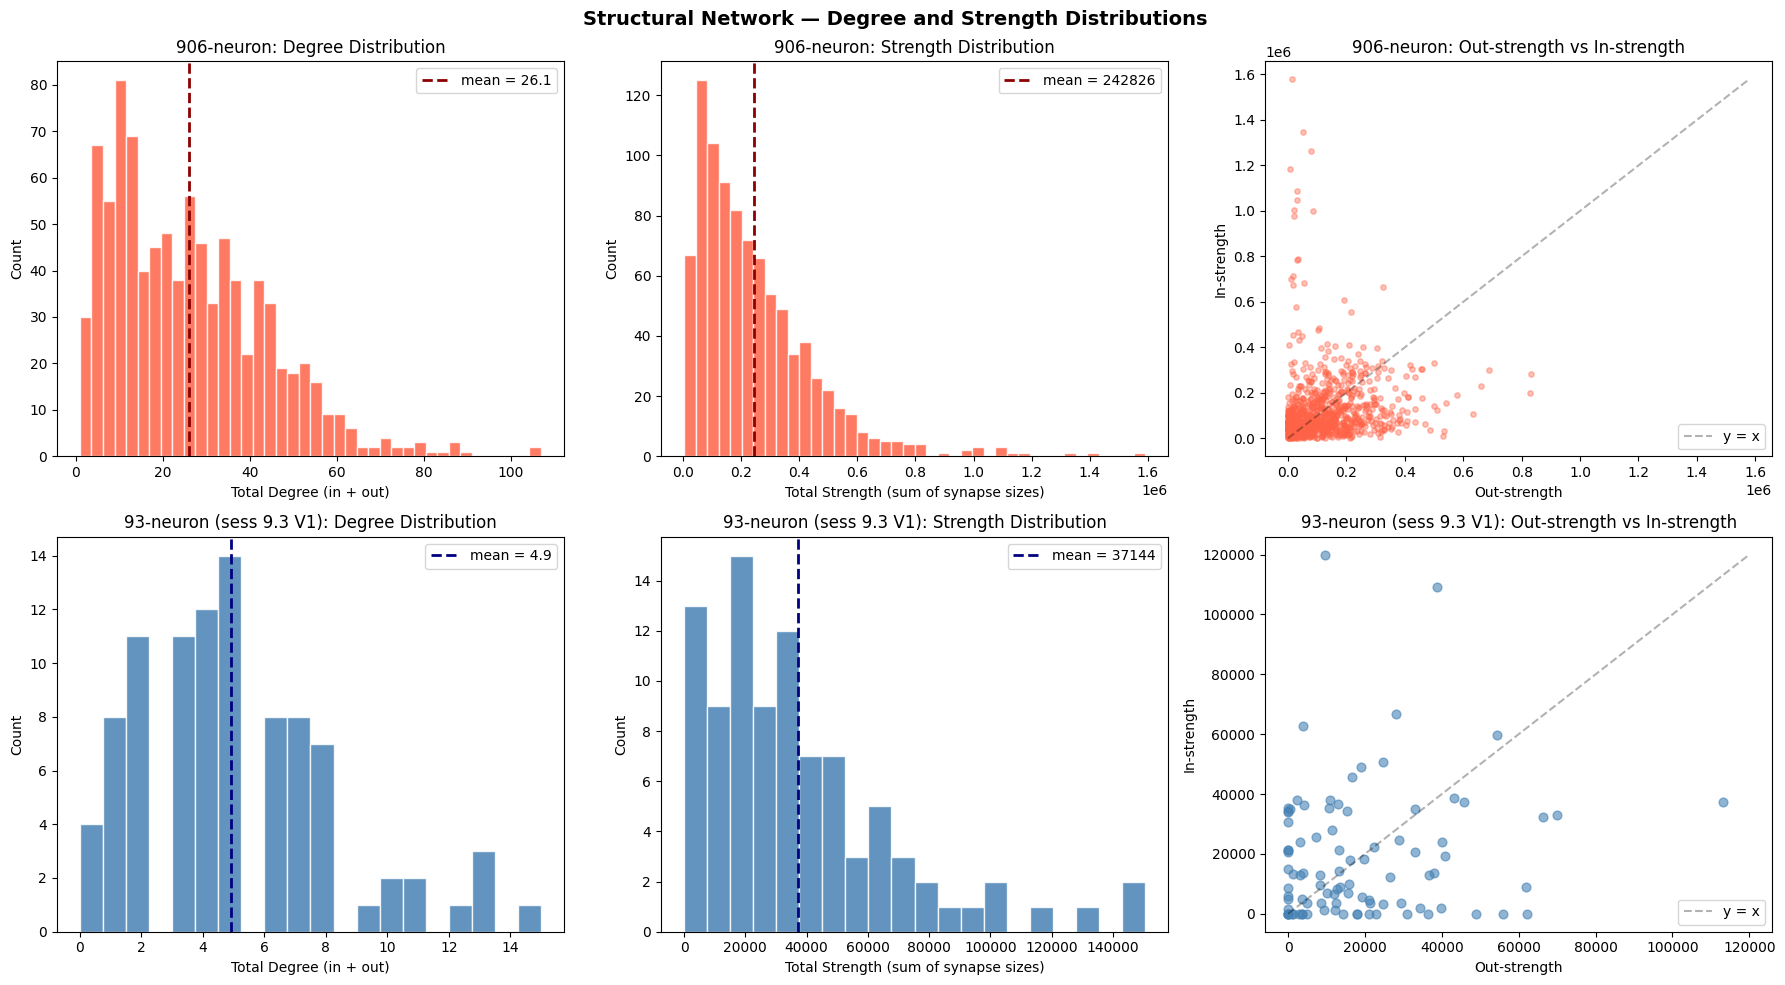

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Row 1: 906-neuron ──
total_deg_906 = out_deg_906 + in_deg_906
axes[0,0].hist(total_deg_906, bins=40, color='tomato', edgecolor='white', alpha=0.85)
axes[0,0].axvline(total_deg_906.mean(), color='darkred', lw=2, linestyle='--',
                  label=f'mean = {total_deg_906.mean():.1f}')
axes[0,0].set_xlabel('Total Degree (in + out)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('906-neuron: Degree Distribution')
axes[0,0].legend()

total_str_906 = out_str_906 + in_str_906
axes[0,1].hist(total_str_906, bins=40, color='tomato', edgecolor='white', alpha=0.85)
axes[0,1].axvline(total_str_906.mean(), color='darkred', lw=2, linestyle='--',
                  label=f'mean = {total_str_906.mean():.0f}')
axes[0,1].set_xlabel('Total Strength (sum of synapse sizes)')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('906-neuron: Strength Distribution')
axes[0,1].legend()

m = max(out_str_906.max(), in_str_906.max())
axes[0,2].scatter(out_str_906, in_str_906, alpha=0.4, s=15, color='tomato')
axes[0,2].plot([0, m], [0, m], 'k--', alpha=0.3, label='y = x')
axes[0,2].set_xlabel('Out-strength')
axes[0,2].set_ylabel('In-strength')
axes[0,2].set_title('906-neuron: Out-strength vs In-strength')
axes[0,2].legend()

# ── Row 2: 93-neuron ──
total_deg_93 = out_deg_93 + in_deg_93
axes[1,0].hist(total_deg_93, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1,0].axvline(total_deg_93.mean(), color='navy', lw=2, linestyle='--',
                  label=f'mean = {total_deg_93.mean():.1f}')
axes[1,0].set_xlabel('Total Degree (in + out)')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('93-neuron (sess 9.3 V1): Degree Distribution')
axes[1,0].legend()

total_str_93 = out_str_93 + in_str_93
axes[1,1].hist(total_str_93, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1,1].axvline(total_str_93.mean(), color='navy', lw=2, linestyle='--',
                  label=f'mean = {total_str_93.mean():.0f}')
axes[1,1].set_xlabel('Total Strength (sum of synapse sizes)')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('93-neuron (sess 9.3 V1): Strength Distribution')
axes[1,1].legend()

if out_str_93.max() > 0:
    m2 = max(out_str_93.max(), in_str_93.max())
    axes[1,2].scatter(out_str_93, in_str_93, alpha=0.6, s=40, color='steelblue')
    axes[1,2].plot([0, m2], [0, m2], 'k--', alpha=0.3, label='y = x')
    axes[1,2].legend()
axes[1,2].set_xlabel('Out-strength')
axes[1,2].set_ylabel('In-strength')
axes[1,2].set_title('93-neuron (sess 9.3 V1): Out-strength vs In-strength')

plt.suptitle('Structural Network — Degree and Strength Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 6 — Synapse Size Distribution

Distribution of individual edge weights. Cortical synapse sizes are typically right-skewed — most are small with a long tail of large ones.

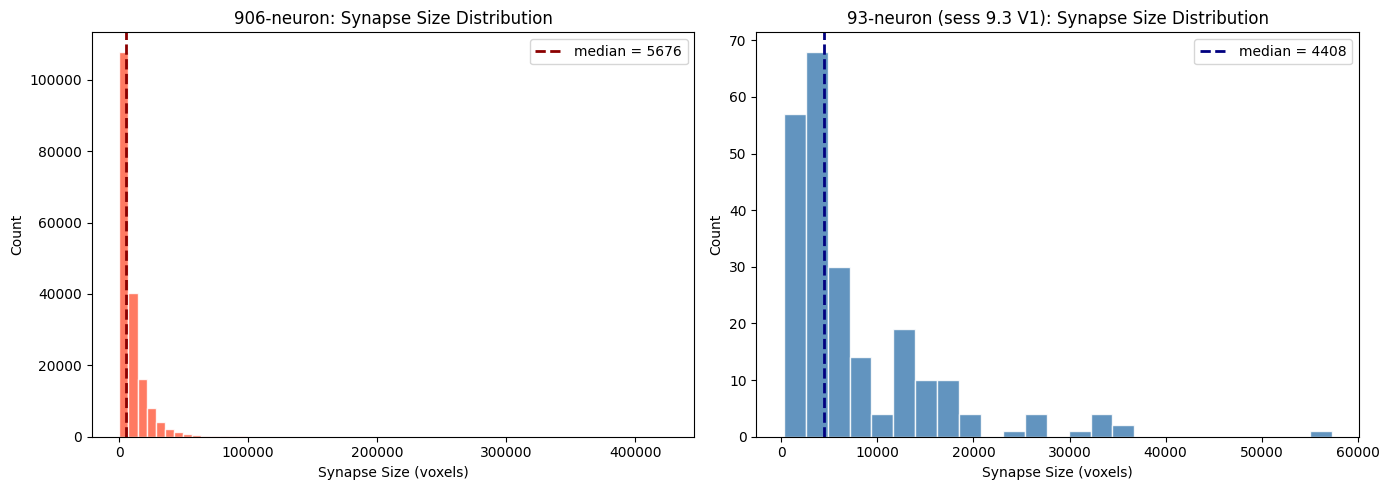

906-network — median: 5676, mean: 9324, skewness: 5.63
93-network  — median: 4408,  mean: 7542,  skewness: 2.40


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weights_906 = synapses['size'].values
axes[0].hist(weights_906, bins=60, color='tomato', edgecolor='white', alpha=0.85)
axes[0].axvline(np.median(weights_906), color='darkred', lw=2, linestyle='--',
                label=f'median = {np.median(weights_906):.0f}')
axes[0].set_xlabel('Synapse Size (voxels)')
axes[0].set_ylabel('Count')
axes[0].set_title('906-neuron: Synapse Size Distribution')
axes[0].legend()

weights_93 = syn_93['size'].values
if len(weights_93) > 0:
    axes[1].hist(weights_93, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[1].axvline(np.median(weights_93), color='navy', lw=2, linestyle='--',
                    label=f'median = {np.median(weights_93):.0f}')
    axes[1].legend()
axes[1].set_xlabel('Synapse Size (voxels)')
axes[1].set_ylabel('Count')
axes[1].set_title('93-neuron (sess 9.3 V1): Synapse Size Distribution')

plt.tight_layout()
plt.show()

print(f"906-network — median: {np.median(weights_906):.0f}, mean: {weights_906.mean():.0f}, skewness: {pd.Series(weights_906).skew():.2f}")
if len(weights_93) > 0:
    print(f"93-network  — median: {np.median(weights_93):.0f},  mean: {weights_93.mean():.0f},  skewness: {pd.Series(weights_93).skew():.2f}")

---
## Part 7 — Network Visualizations

**93-neuron:** Spring layout, edge thickness and opacity proportional to synapse size (log-scaled so both weak and strong synapses are visible).  
**906-neuron:** Actual x/z tissue coordinates. Node size ∝ total strength. Only above-median edges drawn to reduce clutter.

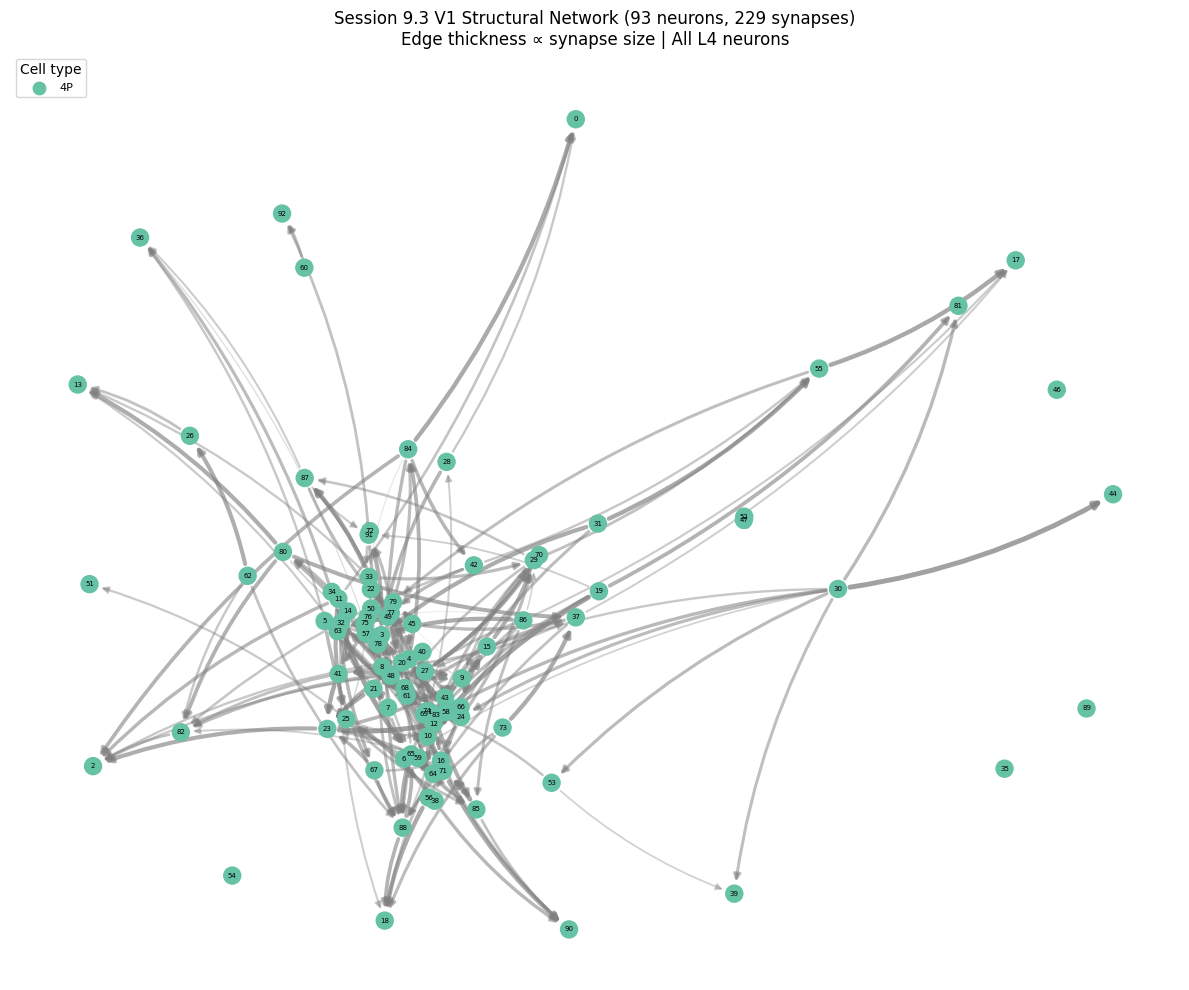

In [11]:
# ── 93-neuron: spring layout ──
fig, ax = plt.subplots(figsize=(12, 10))

np.random.seed(42)
pos_93 = nx.spring_layout(G_93, weight='weight', seed=42, k=0.5)

cell_types_93 = [G_93.nodes[n]['cell_type'] for n in G_93.nodes()]
unique_types  = sorted(set(cell_types_93))
cmap_nodes    = plt.cm.Set2(np.linspace(0, 1, max(len(unique_types), 1)))
color_map     = {ct: cmap_nodes[i] for i, ct in enumerate(unique_types)}
node_colors   = [color_map[ct] for ct in cell_types_93]

edge_w_93 = np.array([G_93[u][v]['weight'] for u, v in G_93.edges()])
if len(edge_w_93) > 0:
    log_w  = np.log1p(edge_w_93)
    norm_w = (log_w - log_w.min()) / (log_w.max() - log_w.min() + 1e-9)
    widths = 0.4 + 3.5 * norm_w
    alphas = 0.2 + 0.6 * norm_w
    for (u, v), w, a in zip(G_93.edges(), widths, alphas):
        nx.draw_networkx_edges(G_93, pos_93, edgelist=[(u, v)], width=float(w),
                               alpha=float(a), edge_color='gray', arrows=True,
                               arrowsize=10, connectionstyle='arc3,rad=0.1', ax=ax)

nx.draw_networkx_nodes(G_93, pos_93, node_color=node_colors, node_size=150, ax=ax)
nx.draw_networkx_labels(G_93, pos_93,
                        labels={n: str(i) for i, n in enumerate(G_93.nodes())},
                        font_size=5, ax=ax)
for ct, c in color_map.items():
    ax.scatter([], [], c=[c], s=80, label=ct)
ax.legend(title='Cell type', loc='upper left', fontsize=8)
ax.set_title(
    f'Session 9.3 V1 Structural Network ({G_93.number_of_nodes()} neurons, {G_93.number_of_edges()} synapses)\n'
    f'Edge thickness ∝ synapse size | All L4 neurons',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.show()

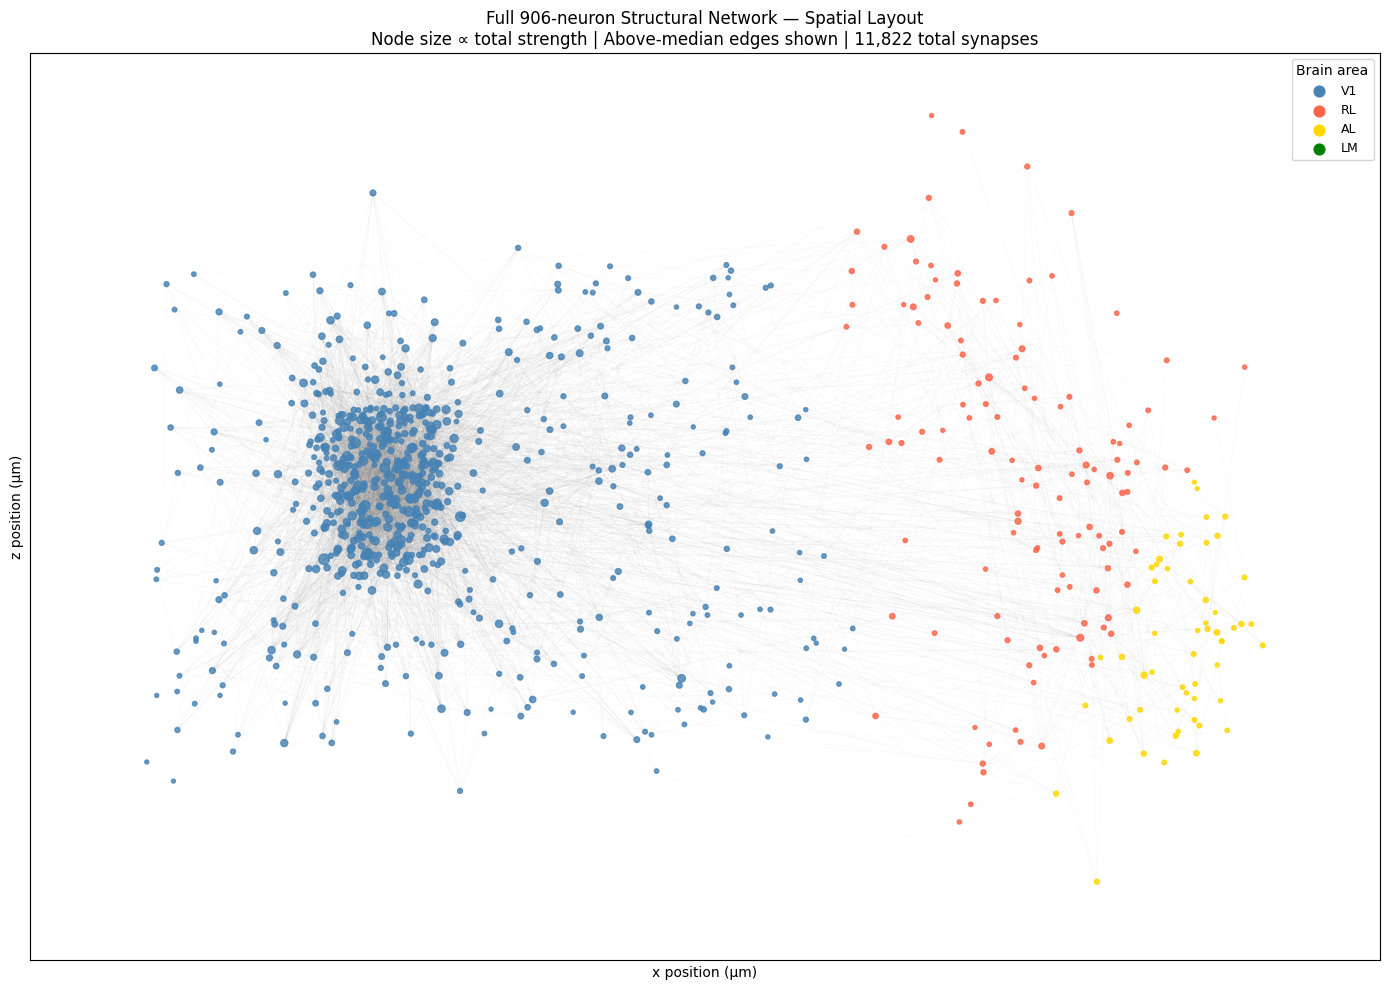

In [12]:
# ── 906-neuron: spatial layout ──
fig, ax = plt.subplots(figsize=(14, 10))

pos_906       = {n: (G_906.nodes[n]['x'], G_906.nodes[n]['z']) for n in G_906.nodes()}
area_colors   = {'V1': 'steelblue', 'RL': 'tomato', 'AL': 'gold', 'LM': 'green'}
node_cols_906 = [area_colors.get(G_906.nodes[n]['brain_area'], 'gray') for n in G_906.nodes()]
total_str_all = np.array([G_906.degree(n, weight='weight') for n in G_906.nodes()])
node_sz       = 8 + 60 * (total_str_all / total_str_all.max())

all_w_906   = np.array([G_906[u][v]['weight'] for u, v in G_906.edges()])
median_w906 = np.median(all_w_906)
heavy_edges = [(u, v) for u, v in G_906.edges() if G_906[u][v]['weight'] >= median_w906]

nx.draw_networkx_edges(G_906, pos_906, edgelist=heavy_edges,
                       alpha=0.06, width=0.4, edge_color='gray', arrows=False, ax=ax)
nx.draw_networkx_nodes(G_906, pos_906, node_color=node_cols_906,
                       node_size=node_sz, alpha=0.8, ax=ax)

for area, color in area_colors.items():
    ax.scatter([], [], c=color, s=60, label=area)
ax.legend(title='Brain area', loc='upper right', fontsize=9)
ax.set_title(
    f'Full 906-neuron Structural Network — Spatial Layout\n'
    f'Node size ∝ total strength | Above-median edges shown | {G_906.number_of_edges():,} total synapses',
    fontsize=12
)
ax.set_xlabel('x position (μm)')
ax.set_ylabel('z position (μm)')
plt.tight_layout()
plt.show()

---
## Part 8 — Summary Table

In [13]:
summary = pd.DataFrame({
    'Metric': [
        'Nodes', 'Edges (synapses)', 'Network density',
        'Mean out-degree', 'Mean in-degree', 'Max out-degree', 'Max in-degree',
        'Mean out-strength (voxels)', 'Mean in-strength (voxels)',
        'Max out-strength (voxels)', 'Max in-strength (voxels)',
        'Median synapse size (voxels)', 'Neurons with zero output', 'Neurons with zero input',
    ],
    'Full 906-neuron': [
        G_906.number_of_nodes(), G_906.number_of_edges(), f"{nx.density(G_906):.4f}",
        f"{out_deg_906.mean():.2f}", f"{in_deg_906.mean():.2f}",
        int(out_deg_906.max()), int(in_deg_906.max()),
        f"{out_str_906.mean():.0f}", f"{in_str_906.mean():.0f}",
        f"{out_str_906.max():.0f}", f"{in_str_906.max():.0f}",
        f"{np.median(weights_906):.0f}",
        int((out_deg_906 == 0).sum()), int((in_deg_906 == 0).sum()),
    ],
    'Session 9.3 V1 (93 neurons)': [
        G_93.number_of_nodes(), G_93.number_of_edges(), f"{nx.density(G_93):.4f}",
        f"{out_deg_93.mean():.2f}", f"{in_deg_93.mean():.2f}",
        int(out_deg_93.max()), int(in_deg_93.max()),
        f"{out_str_93.mean():.0f}", f"{in_str_93.mean():.0f}",
        f"{out_str_93.max():.0f}", f"{in_str_93.max():.0f}",
        f"{np.median(weights_93):.0f}" if len(weights_93) > 0 else 'N/A',
        int((out_deg_93 == 0).sum()), int((in_deg_93 == 0).sum()),
    ]
})

print(summary.to_string(index=False))

                      Metric Full 906-neuron Session 9.3 V1 (93 neurons)
                       Nodes             906                          93
            Edges (synapses)           11822                         229
             Network density          0.0144                      0.0268
             Mean out-degree           13.05                        2.46
              Mean in-degree           13.05                        2.46
              Max out-degree              69                           8
               Max in-degree              98                          11
  Mean out-strength (voxels)          121413                       18572
   Mean in-strength (voxels)          121413                       18572
   Max out-strength (voxels)          830688                      113280
    Max in-strength (voxels)         1578844                      119944
Median synapse size (voxels)            5676                        4408
    Neurons with zero output              34       

In [14]:
# Save both graphs for use in other notebooks
os.makedirs('data', exist_ok=True)

with open('data/G_906.pkl', 'wb') as f:
    pickle.dump(G_906, f)
with open('data/G_93.pkl', 'wb') as f:
    pickle.dump(G_93, f)

print("Saved: data/G_906.pkl  and  data/G_93.pkl")
print("Reload with:  G = pickle.load(open('data/G_906.pkl', 'rb'))")

Saved: data/G_906.pkl  and  data/G_93.pkl
Reload with:  G = pickle.load(open('data/G_906.pkl', 'rb'))
